# SWE-rebench

One subject (Qwen3-Coder-480B-A35B-Instruct in OpenHands v0.54.0) attempts 6,306 GitHub-issue tasks, several times each. A response is 1 if the agent's patch passes the hidden `FAIL_TO_PASS` and `PASS_TO_PASS` tests. 

## 1. Setup

In [1]:
import json
import re
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import yaml
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import NullFormatter

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
B = "swe_rebench"
DIR = ROOT / "data" / B

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 160)

In [2]:
# Plot style. Categorical slots 1–3 of the reference palette; blue = resolved, orange = unresolved.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, SURFACE, GRID = "#0b0b0b", "#52514e", "#8a8984", "#fcfcfb", "#e6e5e1"
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#86b6ef", "#2a78d6", "#1c5cab", "#0d366b"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.axisbelow": True, "axes.spines.right": False, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "xtick.color": INK2, "ytick.color": INK2,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.frameon": False, "legend.fontsize": 8.5,
    "axes.prop_cycle": plt.cycler(color=[BLUE, ORANGE, AQUA]), "lines.linewidth": 2,
    "figure.dpi": 110,
})

In [3]:
# Helpers

def parse_json(s):
    return json.loads(s) if isinstance(s, str) and s.strip() else None


def short(x, n=60):
    x = str(x).replace("\n", " ⏎ ")
    return x if len(x) <= n else x[: n - 1] + "…"


def panels(n, width=5.2, height=3.4):
    fig, axes = plt.subplots(1, n, figsize=(width * n, height), squeeze=False)
    return fig, axes[0]


def show(fig):
    fig.tight_layout()
    plt.show()


def hist(ax, values, title, xlabel, bins=40, logx=False, color=BLUE):
    values = pd.Series(values).dropna()
    if logx:
        values = values[values > 0]
        bins = np.logspace(np.log10(values.min()), np.log10(values.max()), bins)
        ax.set_xscale("log")
    ax.hist(values, bins=bins, color=color, edgecolor=SURFACE, linewidth=0.6)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("count")
    ax.grid(axis="x", visible=False)


def barh(ax, counts, title, xlabel="count", top=20, color=BLUE):
    counts = counts.head(top)[::-1]
    ax.barh([short(i, 40) for i in counts.index], counts.values, color=color, height=0.7)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", visible=False)


def binned_rate(ax, x, y, title, xlabel, q=10, logx=False, clip=None, color=BLUE):
    """Mean of y within quantile bins of x (or per value of a discrete x clipped at `clip`), ±1.96·SE band."""
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    if clip is not None:
        d["x"] = d.x.clip(upper=clip)
        d["bin"] = d.x
    else:
        d["bin"] = pd.qcut(d.x.rank(method="first"), q, labels=False)
    g = d.groupby("bin").agg(x=("x", "median"), y=("y", "mean"), sd=("y", "std"), n=("y", "size"))
    g = g[g.n >= 30]
    se = g.sd / np.sqrt(g.n)
    ax.fill_between(g.x, g.y - 1.96 * se, g.y + 1.96 * se, color=color, alpha=0.18, linewidth=0)
    ax.plot(g.x, g.y, color=color, marker="o", markersize=5)
    if logx:
        ax.set_xscale("log")
        ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_title(title)
    ax.set_xlabel(xlabel + (f" (≥ {clip} pooled)" if clip is not None else ""))
    ax.set_ylabel("resolve rate")
    ax.set_ylim(0, 1)


def auc(score, label):
    """ROC AUC via the Mann–Whitney rank statistic (ties get half credit)."""
    d = pd.DataFrame({"s": score, "y": label}).dropna()
    r = d.s.rank()
    n1, n0 = (d.y == 1).sum(), (d.y == 0).sum()
    return (r[d.y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)


def spearman(a, b):
    return pd.Series(a).corr(pd.Series(b), method="spearman")


DIFF_FILE = re.compile(r"^diff --git a/(\S+) b/", re.M)


def patch_stats(p):
    """File list and line counts of a unified git diff."""
    if not isinstance(p, str) or not p:
        return dict(files=(), new_files=0, added=0, removed=0, hunks=0)
    added = removed = hunks = 0
    for line in p.split("\n"):
        if line.startswith("@@"):
            hunks += 1
        elif line.startswith("+") and not line.startswith("+++"):
            added += 1
        elif line.startswith("-") and not line.startswith("---"):
            removed += 1
    return dict(files=tuple(DIFF_FILE.findall(p)), new_files=p.count("\nnew file mode"),
                added=added, removed=removed, hunks=hunks)


def is_test_path(f):
    f = f.lower()
    return bool(re.search(r"(^|/)(tests?|testing)/|(^|/)test_[^/]*\.py$|_test\.py$|(^|/)conftest\.py$", f))

## 2. Metadata and provenance

### 2.1 `benchmarks.parquet`

In [4]:
bench = pd.read_parquet(DIR / "benchmarks.parquet").iloc[0]
print(textwrap.fill(bench.description, 120), "\n")
display(bench.drop("description").to_frame("value"))

SWE-rebench: an automated, decontaminated benchmark of real-world software-engineering agent tasks. Each task is a
GitHub issue + repo snapshot; an LLM agent must produce a patch verified by the repo test suite (FAIL_TO_PASS /
PASS_TO_PASS). This build ingests the publicly released per-instance trajectories of the OpenHands v0.54.0 +
Qwen3-Coder-480B-A35B-Instruct agent, emitting a binary resolved=1/0 response per (agent, instance, run). 



,value
benchmark_id,swe_rebench
name,SWE-rebench
version,NaN
license,CC-BY-4.0
source_url,https://huggingface.co/datasets/nebius/SWE-rebench-openhands-trajectories
one_line_description,NaN
modality,[text]
domain,"[software_engineering, agents_and_tool_use]"
multi_single_turn,multi_turn
response_type,binary


### 2.2 `metadata.yaml`, `characterization.yaml` and the build's source claims

In [5]:
meta = yaml.safe_load((DIR / "metadata.yaml").read_text())
char = yaml.safe_load((DIR / "characterization.yaml").read_text())
print("testing_condition:\n" + textwrap.fill(meta["benchmark"]["testing_condition"], 120), "\n")
print("upstream sources:")
for s in meta["sources"]["upstream"]:
    print(f"  {s['url']}  @ {s['revision']}")

rows = {t: pq.ParquetFile(DIR / f"{'response' if t == 'responses' else t}.parquet").metadata.num_rows
        for t in char["tables"]}
display(pd.DataFrame({
    "declared_rows": {t: v["rows"] for t, v in char["tables"].items()},
    "actual_rows": rows,
}).assign(match=lambda d: d.declared_rows == d.actual_rows))
display(pd.DataFrame({k: {"expected": v["expected"], "scope": short(v["scope"], 110)}
                      for k, v in char["source_claims"].items()}).T)

testing_condition:
Single public agent: Qwen3-Coder-480B-A35B-Instruct is the subject label and the OpenHands v0.54.0 scaffold lands on
`harness` / `harness_version` at subject registration, so both make up subject identity. response is binary: 1 if the
agent patch passed the hidden FAIL_TO_PASS / PASS_TO_PASS tests (released `resolved` flag), else 0. Repeat runs of the
same instance are separate trials. No test_condition (the trajectory release carries no monthly-slice label). 

upstream sources:
  https://huggingface.co/datasets/nebius/SWE-rebench  @ None
  https://huggingface.co/datasets/nebius/SWE-rebench-openhands-trajectories  @ None
  https://github.com/All-Hands-AI/OpenHands  @ 4aae68ae53477d05010a509f1f1e3f02e61b1831
  https://github.com/SWE-rebench/SWE-bench-fork  @ e4907b7a90eafaa1f0a6428fd04fe31cdd8b4284
  https://huggingface.co/datasets/nebius/SWE-rebench  @ 89cdfbab4ab1bd8f5a658bb212d1b63624f4f881


,declared_rows,actual_rows,match
benchmarks,1,1,True
items,6306,6306,True
responses,67074,67074,True
subjects,1,1,True
traces,67018,67018,True


,expected,scope
released_responses,67074,Archived OpenHands trajectory rows with a non-null resolved flag; repeated r...
released_traces,67018,Archived OpenHands trajectory rows with a non-null resolved flag; repeated r...


All declared row counts match. Note the two claims: 67,074 responses but only 67,018 traces — 56 runs
produced an **empty patch** (they still have a resolved flag, see §9).

`metadata.yaml` lists `nebius/SWE-rebench` twice (once unpinned, once at `89cdfbab`), and the benchmark
`release_date` (2025-05) is the benchmark's, not the trajectory release's.

## 3. Subject

In [6]:
subjects = pd.read_parquet(DIR / "subjects.parquet")
display(subjects.T.rename(columns={0: "value"}))

,value
subject_id,58c3de46be1beb60
display_name,Qwen3-Coder-480B-A35B-Instruct
normalized_name,Alibaba Qwen3-Coder 480B
provider,Alibaba
release_date,2025-07-22
access_date,NaN
harness,OpenHands
reasoning_effort,NaN
harness_version,v0.54.0
subject_features_extra,NaN


A single agent: Qwen3-Coder-480B-A35B-Instruct (Alibaba, released 2025-07-22) inside OpenHands v0.54.0.
`reasoning_effort` and `access_date` are empty. With one subject there is no ability dimension to model
here — this benchmark contributes **item** information (difficulty, run-to-run variability), and any
cross-benchmark use has to go through this one model.

## 4. Items

### 4.1 Structure and integrity

In [7]:
items = pd.read_parquet(DIR / "items.parquet")
print(f"{len(items):,} items · item_id unique: {items.item_id.is_unique} · raw_item_id unique: "
      f"{items.raw_item_id.is_unique}")
print("columns entirely null:", [c for c in items if items[c].isna().all()])

crit = items.grading_criterion.map(parse_json)
ver = items.verifier.map(parse_json)
spec = ver.map(lambda v: parse_json(v["spec"]))
print("grading_criterion keys:", sorted({k for d in crit for k in d}))
print("verifier class:", ver.map(lambda v: v["class"]).value_counts().to_dict(),
      "· spec kind:", spec.map(lambda s: s["kind"]).value_counts().to_dict())
print("spec keys:", sorted({k for d in spec for k in d}))
print("reference_answer == spec.patch:", (crit.map(lambda d: d["reference_answer"]) == spec.map(lambda s: s["patch"])).all())

items = items.assign(
    repo=items.raw_item_id.str.rsplit("-", n=1).str[0].str.replace("__", "/", n=1),
    gold_patch=spec.map(lambda s: s["patch"]),
    test_patch=spec.map(lambda s: s["test_patch"]),
    f2p=spec.map(lambda s: len(s["FAIL_TO_PASS"])),
    p2p=spec.map(lambda s: len(s["PASS_TO_PASS"])),
    docker_image=spec.map(lambda s: s["docker_image"]),
)
print("distinct docker images:", items.docker_image.nunique())

6,306 items · item_id unique: True · raw_item_id unique: True
columns entirely null: ['asset_manifest', 'item_features']


grading_criterion keys: ['reference_answer', 'rule']
verifier class: {'exact_matcher': 6306} · spec kind: {'swebench_harness': 6306}
spec keys: ['FAIL_TO_PASS', 'PASS_TO_PASS', 'docker_image', 'kind', 'patch', 'test_patch']
reference_answer == spec.patch: True
distinct docker images: 5731


- `item_features` and `asset_manifest` are empty: the harmonised table carries **no item metadata** beyond
  the problem text. Everything useful (repo, gold patch, tests) sits in the JSON `verifier.spec`, which is
  parsed above.
- The verifier is labelled `exact_matcher` but is really the SWE-bench test harness (`kind: swebench_harness`).
- One Docker image per item.

### 4.2 Consistency with the raw upstream files

In [8]:
traj = pd.read_parquet(DIR / "raw" / "openhands_trajectories.parquet")
inst = pd.read_parquet(DIR / "raw" / "instances.parquet",
                       columns=["instance_id", "problem_statement", "patch", "FAIL_TO_PASS", "PASS_TO_PASS"])
print(f"raw trajectories: {len(traj):,} rows · {traj.instance_id.nunique():,} instances · "
      f"{traj.repo.nunique():,} repos")
print(f"raw instance pool: {len(inst):,} instances, of which {inst.instance_id.isin(items.raw_item_id).sum():,} "
      f"have trajectories ({inst.instance_id.isin(items.raw_item_id).mean():.1%})")

chk = items.merge(inst, left_on="raw_item_id", right_on="instance_id", how="left")
print("items.content == raw problem_statement:", (chk.content == chk.problem_statement).mean())
print("gold patch == raw patch:", (chk.gold_patch == chk.patch).mean())
print("FAIL_TO_PASS count matches:", (chk.f2p == chk.FAIL_TO_PASS.map(len)).mean())
repo_raw = traj.drop_duplicates("instance_id").set_index("instance_id").repo
print("repo parsed from id == raw repo:", (items.repo.values == repo_raw.reindex(items.raw_item_id).values).mean())

raw trajectories: 67,074 rows · 6,306 instances · 1,823 repos
raw instance pool: 21,336 instances, of which 6,306 have trajectories (29.6%)
items.content == raw problem_statement: 1.0
gold patch == raw patch: 1.0
FAIL_TO_PASS count matches: 1.0
repo parsed from id == raw repo: 1.0


### 4.3 Item characteristics

,count,mean,std,min,5%,25%,50%,75%,95%,max
ps_chars,6306.0,1529.0,2624.1,33.0,183.0,440.0,857.0,1671.0,4622.0,51476.0
gold_files,6306.0,2.2,1.6,1.0,1.0,1.0,2.0,3.0,5.0,60.0
gold_lines,6306.0,35.0,63.8,1.0,2.0,7.0,17.0,39.0,129.0,2512.0
gold_hunks,6306.0,4.4,4.3,1.0,1.0,2.0,3.0,6.0,12.0,72.0
f2p,6306.0,3.7,33.3,1.0,1.0,1.0,1.0,2.0,9.0,2364.0
p2p,6306.0,55.8,143.6,0.0,0.0,7.0,19.0,50.0,205.0,2976.0
test_files,6306.0,1.5,1.7,0.0,1.0,1.0,1.0,2.0,3.0,82.0
test_lines,6306.0,51.8,270.1,1.0,3.0,10.0,20.0,45.0,144.8,13429.0


problem statements with a code block: 60.1% · mentioning an error/traceback: 27.7%
gold patch touches a single file: 41.6% · adds new files: 8.2%


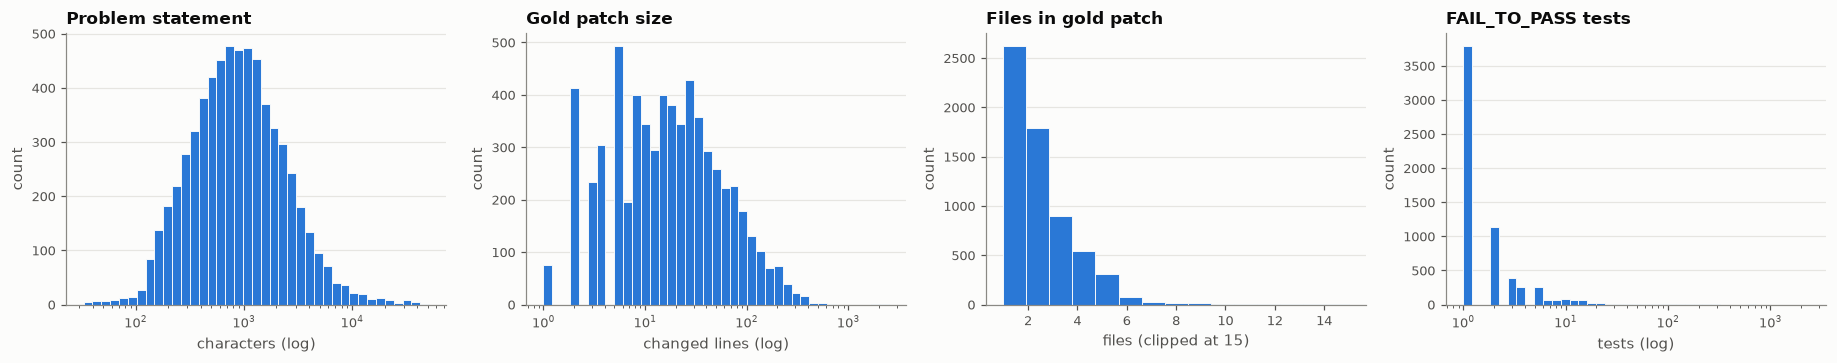

In [9]:
gold = pd.DataFrame([patch_stats(p) for p in items.gold_patch], index=items.index)
tpatch = pd.DataFrame([patch_stats(p) for p in items.test_patch], index=items.index)
items = items.assign(
    ps_chars=items.content.str.len(),
    ps_has_code=items.content.str.contains("```"),
    ps_has_traceback=items.content.str.contains("Traceback|Error:|Exception", regex=True),
    gold_files=gold.files.map(len),
    gold_lines=gold.added + gold.removed,
    gold_hunks=gold.hunks,
    gold_new_files=gold.new_files,
    gold_file_set=gold.files.map(frozenset),
    test_files=tpatch.files.map(len),
    test_lines=tpatch.added + tpatch.removed,
)
FEATURES = ["ps_chars", "gold_files", "gold_lines", "gold_hunks", "f2p", "p2p", "test_files", "test_lines"]
display(items[FEATURES].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T.round(1))
print(f"problem statements with a code block: {items.ps_has_code.mean():.1%} · "
      f"mentioning an error/traceback: {items.ps_has_traceback.mean():.1%}")
print(f"gold patch touches a single file: {(items.gold_files == 1).mean():.1%} · adds new files: "
      f"{(items.gold_new_files > 0).mean():.1%}")

fig, axes = panels(4, width=4.2)
hist(axes[0], items.ps_chars, "Problem statement", "characters (log)", logx=True)
hist(axes[1], items.gold_lines, "Gold patch size", "changed lines (log)", logx=True)
hist(axes[2], items.gold_files.clip(upper=15), "Files in gold patch", "files (clipped at 15)", bins=15)
hist(axes[3], items.f2p, "FAIL_TO_PASS tests", "tests (log)", logx=True)
show(fig)

Items are typical SWE-bench-style tasks: a median problem statement of ~1k characters and small gold
fixes (median tens of changed lines, most in one or two files). The number of FAIL_TO_PASS tests is
heavy-tailed.

### 4.4 Duplicate problem statements

In [10]:
dup = items[items.content.duplicated(keep=False)].sort_values("content")
print(f"{len(dup)} items share their problem statement with another item "
      f"({dup.content.nunique()} distinct statements); content_hash duplicates: {items.content_hash.duplicated().sum()}")
print("same repo within each group:", dup.groupby("content").repo.nunique().eq(1).all(),
      "· same gold patch within each group:", dup.groupby("content").gold_patch.nunique().eq(1).mean().round(2))
display(dup.groupby("content").agg(n=("raw_item_id", "size"), ids=("raw_item_id", lambda s: ", ".join(s)))
        .reset_index(drop=True).head(10))

68 items share their problem statement with another item (33 distinct statements); content_hash duplicates: 35
same repo within each group: True · same gold patch within each group: 0.03


,n,ids
0,2,"ESSS__conda-devenv-51, ESSS__conda-devenv-50"
1,2,"python-pillow__Pillow-5606, python-pillow__Pillow-5594"
2,2,"ramonhagenaars__nptyping-55, ramonhagenaars__nptyping-54"
3,2,"mwouts__jupytext-1180, mwouts__jupytext-1175"
4,2,"anchore__anchore-cli-101, anchore__anchore-cli-107"
5,2,"CSCfi__swift-browser-ui-20, CSCfi__swift-browser-ui-21"
6,2,"google__mobly-164, google__mobly-165"
7,2,"Textualize__textual-2530, Textualize__textual-3896"
8,2,"borgbackup__borg-7942, borgbackup__borg-7941"
9,2,"borgbackup__borg-7492, borgbackup__borg-7549"


Different upstream PRs sometimes resolve the same issue, so the problem statement repeats while the
gold patch and tests differ. These are distinct tasks for grading, but a text-only difficulty model will
see identical inputs with different labels — and a random item-level split can leak across them.
Split by repository or by `content_hash` group.

### 4.5 Is the 6,306-item subset representative of the full pool?

In [11]:
pool = inst.assign(
    in_subset=inst.instance_id.isin(items.raw_item_id),
    ps_chars=inst.problem_statement.str.len(),
    gold_lines=[(s := patch_stats(p))["added"] + s["removed"] for p in inst.patch],
    f2p=inst.FAIL_TO_PASS.map(len),
)
display(pool.groupby("in_subset")[["ps_chars", "gold_lines", "f2p"]].median()
        .rename(index={True: "with trajectories", False: "rest of pool"}).rename_axis("median"))

,ps_chars,gold_lines,f2p
median,,,
rest of pool,649.5,56.5,2.0
with trajectories,857.0,17.0,1.0


The trajectory release covers only 30% of the upstream pool, and it is **not a random 30%**: its gold
fixes are about 3× smaller (median 17 vs 56 changed lines) and need fewer FAIL_TO_PASS tests. Resolve
rates here are therefore optimistic relative to the full SWE-rebench pool, and difficulty models trained
here see a truncated range of task sizes.

## 5. Responses: trials, success rates and run-to-run noise

### 5.1 Structure

In [12]:
resp = pd.read_parquet(DIR / "response.parquet")
print(f"{len(resp):,} responses · response_id unique: {resp.response_id.is_unique} · missing scores: "
      f"{resp.response.isna().sum()} · values: {sorted(resp.response.unique())}")
print("test_condition / interactors all null:", resp.test_condition.isna().all(), resp.interactors.isna().all())
print("duplicate (item, trial):", resp.duplicated(["item_id", "trial"]).sum(),
      "· orphan items:", (~resp.item_id.isin(items.item_id)).sum())

# Raw trajectories are in the same row order as responses; trial = running count per instance.
resp = resp.merge(items[["item_id", "raw_item_id", "repo"]], on="item_id", how="left")
assert (resp.raw_item_id.values == traj.instance_id.values).all()
assert (resp.response.values == traj.resolved.values).all()
assert (traj.groupby("instance_id").cumcount().values + 1 == resp.trial.values).all()
resp["exit_status"] = traj.exit_status.values
resp["trajectory_id"] = traj.trajectory_id.values
print("row-aligned with raw trajectories: resolved flags, ids and trial order all match")

per_item = resp.groupby("item_id").response.agg(n="size", c="sum")
per_item["rate"] = per_item.c / per_item.n
trials_contig = resp.groupby("item_id").trial.agg(["max", "size"]).pipe(lambda d: (d["max"] == d["size"]).all())
print(f"trials per item: min {per_item.n.min()}, median {per_item.n.median():.0f}, max {per_item.n.max()} · "
      f"trial numbers contiguous: {trials_contig}")
print(f"overall resolve rate (per run): {resp.response.mean():.3f} · macro (mean of item rates): "
      f"{per_item.rate.mean():.3f}")

67,074 responses · response_id unique: True · missing scores: 0 · values: [np.float64(0.0), np.float64(1.0)]
test_condition / interactors all null: True True
duplicate (item, trial): 0 · orphan items: 0
row-aligned with raw trajectories: resolved flags, ids and trial order all match
trials per item: min 1, median 10, max 34 · trial numbers contiguous: True
overall resolve rate (per run): 0.479 · macro (mean of item rates): 0.476


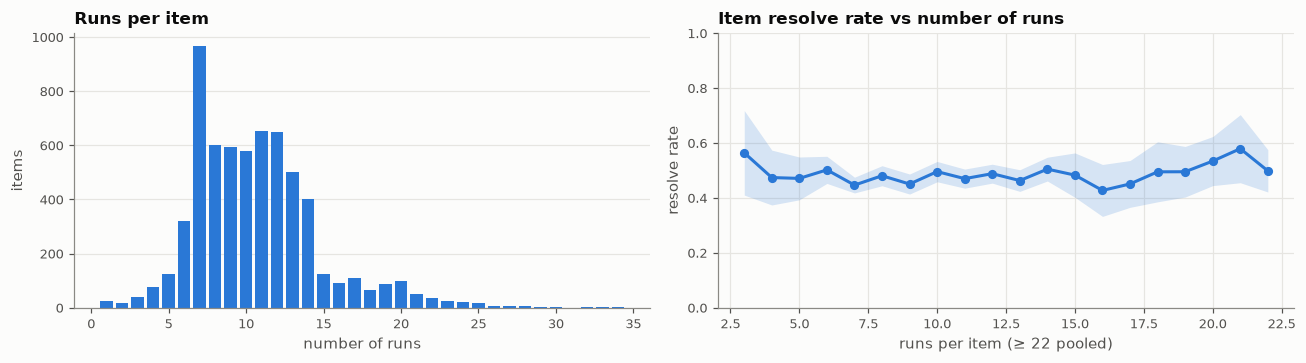

Spearman(runs per item, item rate): +0.014


In [13]:
fig, axes = panels(2, width=6)
vc = per_item.n.value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color=BLUE, width=0.8)
axes[0].set_title("Runs per item")
axes[0].set_xlabel("number of runs")
axes[0].set_ylabel("items")
axes[0].grid(axis="x", visible=False)
binned_rate(axes[1], per_item.n, per_item.rate, "Item resolve rate vs number of runs", "runs per item", clip=22)
show(fig)
print(f"Spearman(runs per item, item rate): {spearman(per_item.n, per_item.rate):+.3f}")

The number of runs per item is **not constant** (1–34, median 10; 24 items have a single run), so the
design is unbalanced. It does not look informative, though: the number of runs is uncorrelated with the
item's resolve rate (Spearman ≈ 0.01), and the per-run (0.479) and per-item macro (0.476) resolve rates
agree. Weighting by runs is harmless here.

### 5.2 Item success rates and pass@k

items with ≥ 2 runs: 6,282 · always solved 32.5% · never solved 39.8% · mixed 27.7%


,pass@k,items
1,0.476,6306.0
2,0.526,6282.0
3,0.550,6264.0
5,0.575,6148.0
7,0.586,5703.0
10,0.612,3540.0
15,0.624,752.0
20,0.683,275.0


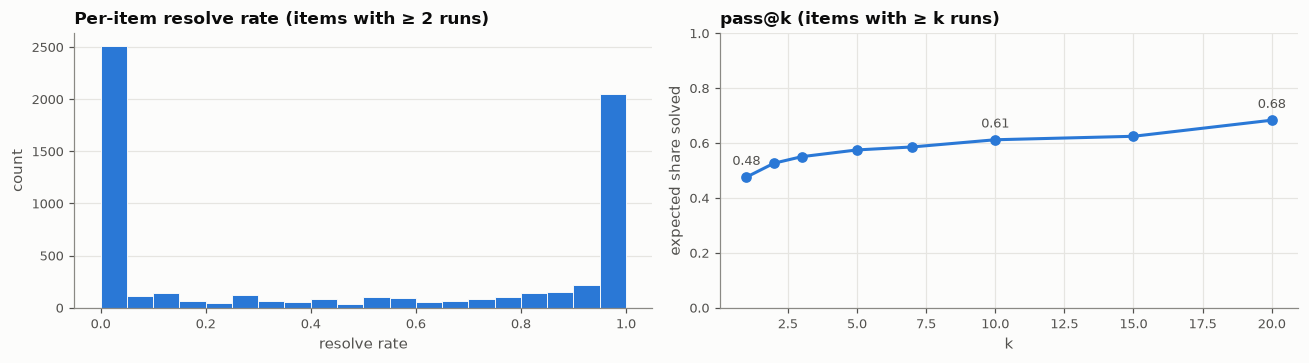

In [14]:
def pass_at_k(n, c, k):
    """Unbiased pass@k estimator (Chen et al., 2021)."""
    if n - c < k:
        return 1.0
    return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))


multi = per_item[per_item.n >= 2]
always, never = (multi.rate == 1).mean(), (multi.rate == 0).mean()
print(f"items with ≥ 2 runs: {len(multi):,} · always solved {always:.1%} · never solved {never:.1%} · "
      f"mixed {1 - always - never:.1%}")

ks = [1, 2, 3, 5, 7, 10, 15, 20]
curve = pd.DataFrame({k: {"pass@k": per_item[per_item.n >= k].apply(lambda r: pass_at_k(r.n, r.c, k), axis=1).mean(),
                          "items": (per_item.n >= k).sum()} for k in ks}).T
display(curve.round(3))

fig, axes = panels(2, width=6)
hist(axes[0], multi.rate, "Per-item resolve rate (items with ≥ 2 runs)", "resolve rate", bins=20)
axes[1].plot(curve.index, curve["pass@k"], color=BLUE, marker="o", markersize=6)
for k in [1, 10, 20]:
    axes[1].annotate(f"{curve.loc[k, 'pass@k']:.2f}", (k, curve.loc[k, "pass@k"]), xytext=(0, 8),
                     textcoords="offset points", ha="center", color=INK2, fontsize=8.5)
axes[1].set_ylim(0, 1)
axes[1].set_title("pass@k (items with ≥ k runs)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("expected share solved")
show(fig)

Item rates are strongly U-shaped: 32.5% of items are always solved, 39.8% never, and 27.7% are mixed.
pass@k climbs from 0.48 (k = 1) to ~0.61 (k = 10), so roughly one in eight tasks is solvable by the agent
but is lost to run-to-run randomness at k = 1. (The k ≥ 15 points use a shrinking subset of items and
are not directly comparable.)

### 5.3 How reliable is a single run? Split-half and noise decomposition

In [15]:
r2 = resp[resp.item_id.isin(per_item.index[per_item.n >= 4])]
half = r2.assign(h=r2.trial % 2).groupby(["item_id", "h"]).response.mean().unstack()
rho = half[0].corr(half[1])
print(f"split-half (odd vs even runs) Pearson r of item rates: {rho:.3f} "
      f"· Spearman–Brown full-length reliability: {2 * rho / (1 + rho):.3f}  ({len(half):,} items with ≥ 4 runs)")

# Observed variance of item rates = true between-item variance + binomial sampling noise.
obs_var = per_item.rate.var()
noise = (per_item.rate * (1 - per_item.rate) / (per_item.n - 1).where(per_item.n > 1)).mean()
print(f"variance of observed item rates {obs_var:.4f} · mean sampling noise {noise:.4f} · "
      f"share of variance that is between-item signal: {1 - noise / obs_var:.1%}")

# Single-run agreement: probability two random runs of the same item agree.
m = per_item[per_item.n >= 2]
p_agree = ((m.c * (m.c - 1) + (m.n - m.c) * (m.n - m.c - 1)) / (m.n * (m.n - 1))).mean()
print(f"P(two runs of the same item agree) = {p_agree:.3f} (vs {1 - 2 * resp.response.mean() * (1 - resp.response.mean()):.3f} "
      f"if outcomes were independent of the item)")

split-half (odd vs even runs) Pearson r of item rates: 0.949 · Spearman–Brown full-length reliability: 0.974  (6,225 items with ≥ 4 runs)
variance of observed item rates 0.2045 · mean sampling noise 0.0055 · share of variance that is between-item signal: 97.3%
P(two runs of the same item agree) = 0.899 (vs 0.501 if outcomes were independent of the item)


Item difficulty is extremely stable: split-half r = 0.95 (reliability 0.97 at full length), and 97% of
the variance in observed item rates is real between-item signal rather than binomial noise. Two runs of
the same item agree 90% of the time. So the per-item rate `c / n` is a solid difficulty label, and the
remaining single-run noise is concentrated in the ~28% of mixed items.

### 5.4 Does the run index matter?

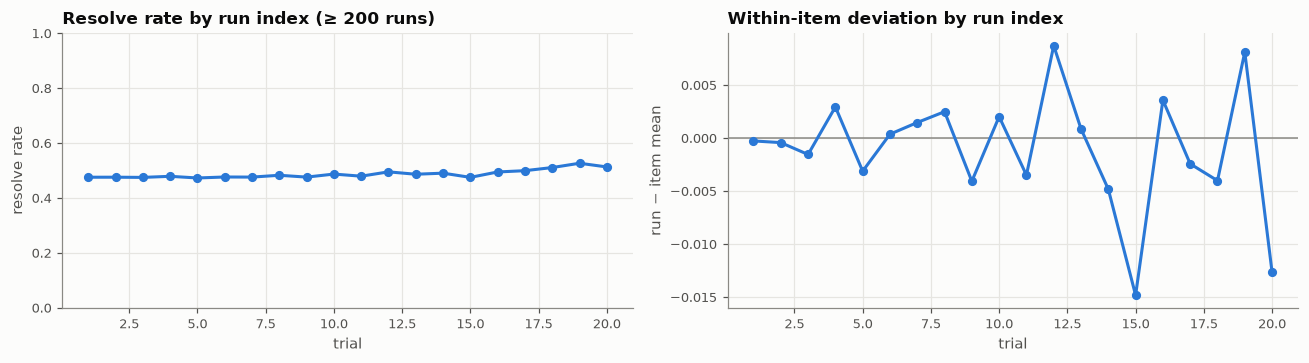

In [16]:
by_trial = resp.groupby("trial").response.agg(rate="mean", n="size")
# Within-item comparison removes the composition effect (items with many runs differ from those with few).
resp["item_rate_loo"] = (resp.groupby("item_id").response.transform("sum") - resp.response) / \
                        (resp.groupby("item_id").response.transform("size") - 1)
resid = (resp.response - resp.groupby("item_id").response.transform("mean")).groupby(resp.trial).mean()

fig, axes = panels(2, width=6)
t = by_trial[by_trial.n >= 200]
axes[0].plot(t.index, t.rate, color=BLUE, marker="o", markersize=5)
axes[0].set_ylim(0, 1)
axes[0].set_title("Resolve rate by run index (≥ 200 runs)")
axes[0].set_xlabel("trial")
axes[0].set_ylabel("resolve rate")
axes[1].axhline(0, color=MUTED, linewidth=1)
axes[1].plot(resid.index[: len(t)], resid.values[: len(t)], color=BLUE, marker="o", markersize=5)
axes[1].set_title("Within-item deviation by run index")
axes[1].set_xlabel("trial")
axes[1].set_ylabel("run − item mean")
show(fig)

The raw curve mixes run index with item composition (only some items get many runs). The within-item
deviation isolates the run effect and stays close to zero, so trial number carries no information and
runs can be treated as exchangeable repeats.

## 6. Why runs fail: agent exit status

`exit_status` is only in the raw trajectory release; it is not carried into the harmonised tables.

In [17]:
def exit_group(s):
    if s == "submit":
        return "submitted"
    if "maximum iteration" in s:
        return "hit 100-step limit"
    if "stuck in a loop" in s:
        return "stuck in loop"
    if "Timeout" in s or "ServiceUnavailable" in s:
        return "API timeout / unavailable"
    return "other error"


resp["exit_group"] = resp.exit_status.map(exit_group)
eg = resp.groupby("exit_group").response.agg(runs="size", resolve_rate="mean").sort_values("runs", ascending=False)
eg["share"] = eg.runs / eg.runs.sum()
display(eg[["runs", "share", "resolve_rate"]].round(3))
print("raw exit_status values:", resp.exit_status.nunique())

,runs,share,resolve_rate
exit_group,,,
submitted,60739,0.906,0.511
hit 100-step limit,6003,0.089,0.182
stuck in loop,252,0.004,0.079
API timeout / unavailable,65,0.001,0.369
other error,15,0.000,0.267


raw exit_status values: 7


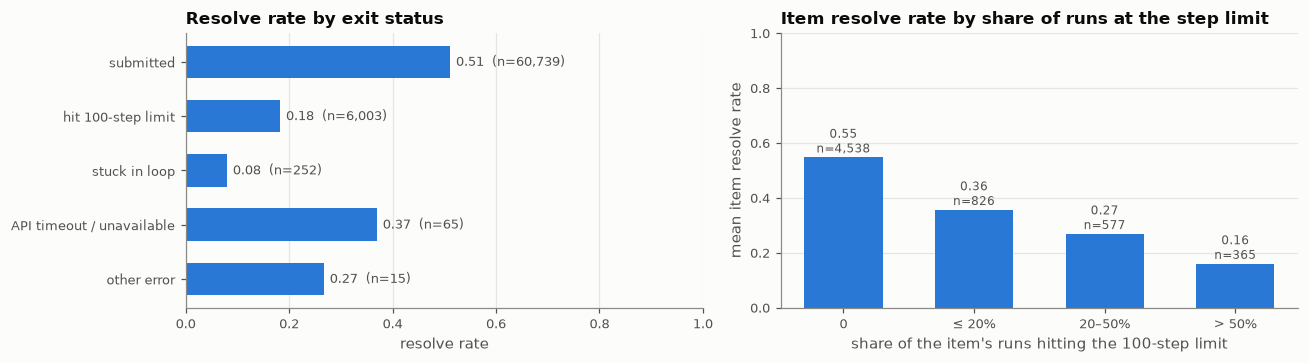

Spearman(item step-limit share, item rate): -0.271


In [18]:
item_exit = resp.assign(limit=resp.exit_group == "hit 100-step limit").groupby("item_id").agg(
    limit_share=("limit", "mean"), rate=("response", "mean"))
fig, axes = panels(2, width=6)
order = eg.index
axes[0].barh(order[::-1], eg.resolve_rate[::-1], color=BLUE, height=0.6)
for y, (v, n) in enumerate(zip(eg.resolve_rate[::-1], eg.runs[::-1])):
    axes[0].annotate(f"{v:.2f}  (n={n:,})", (v, y), xytext=(4, 0), textcoords="offset points", va="center",
                     fontsize=8.5, color=INK2)
axes[0].set_xlim(0, 1)
axes[0].set_title("Resolve rate by exit status")
axes[0].set_xlabel("resolve rate")
axes[0].grid(axis="y", visible=False)
buckets = pd.cut(item_exit.limit_share, [-0.01, 0, 0.2, 0.5, 1], labels=["0", "≤ 20%", "20–50%", "> 50%"])
g = item_exit.groupby(buckets, observed=True).rate.agg(["mean", "size"])
axes[1].bar(g.index.astype(str), g["mean"], color=BLUE, width=0.6)
for x, (v, n) in enumerate(zip(g["mean"], g["size"])):
    axes[1].annotate(f"{v:.2f}\nn={n:,}", (x, v), xytext=(0, 3), textcoords="offset points", ha="center",
                     fontsize=8, color=INK2)
axes[1].set_ylim(0, 1)
axes[1].set_title("Item resolve rate by share of runs at the step limit")
axes[1].set_xlabel("share of the item's runs hitting the 100-step limit")
axes[1].set_ylabel("mean item resolve rate")
axes[1].grid(axis="x", visible=False)
show(fig)
print(f"Spearman(item step-limit share, item rate): {spearman(item_exit.limit_share, item_exit.rate):+.3f}")

- 90.6% of runs end with a normal `submit` (resolve rate 0.51). The 100-step limit is the main failure
  mode: 8.9% of runs, resolve rate 0.18. Runs at the limit can still pass because OpenHands grades
  whatever edits exist at that point, so a non-`submit` exit is **not** an automatic 0.
- Items whose runs often hit the step limit are harder (Spearman −0.27 between an item's step-limit
  share and its resolve rate).
- Infrastructure failures (API timeouts, service unavailable, an `AttributeError` in the scaffold, 80
  runs) are rare. Their zeros say nothing about the item and could be dropped or treated as missing.

## 7. Repositories

1,823 repos · items per repo: median 1, max 275 · repos with a single item: 52.9%
top 20 repos hold 19.6% of items


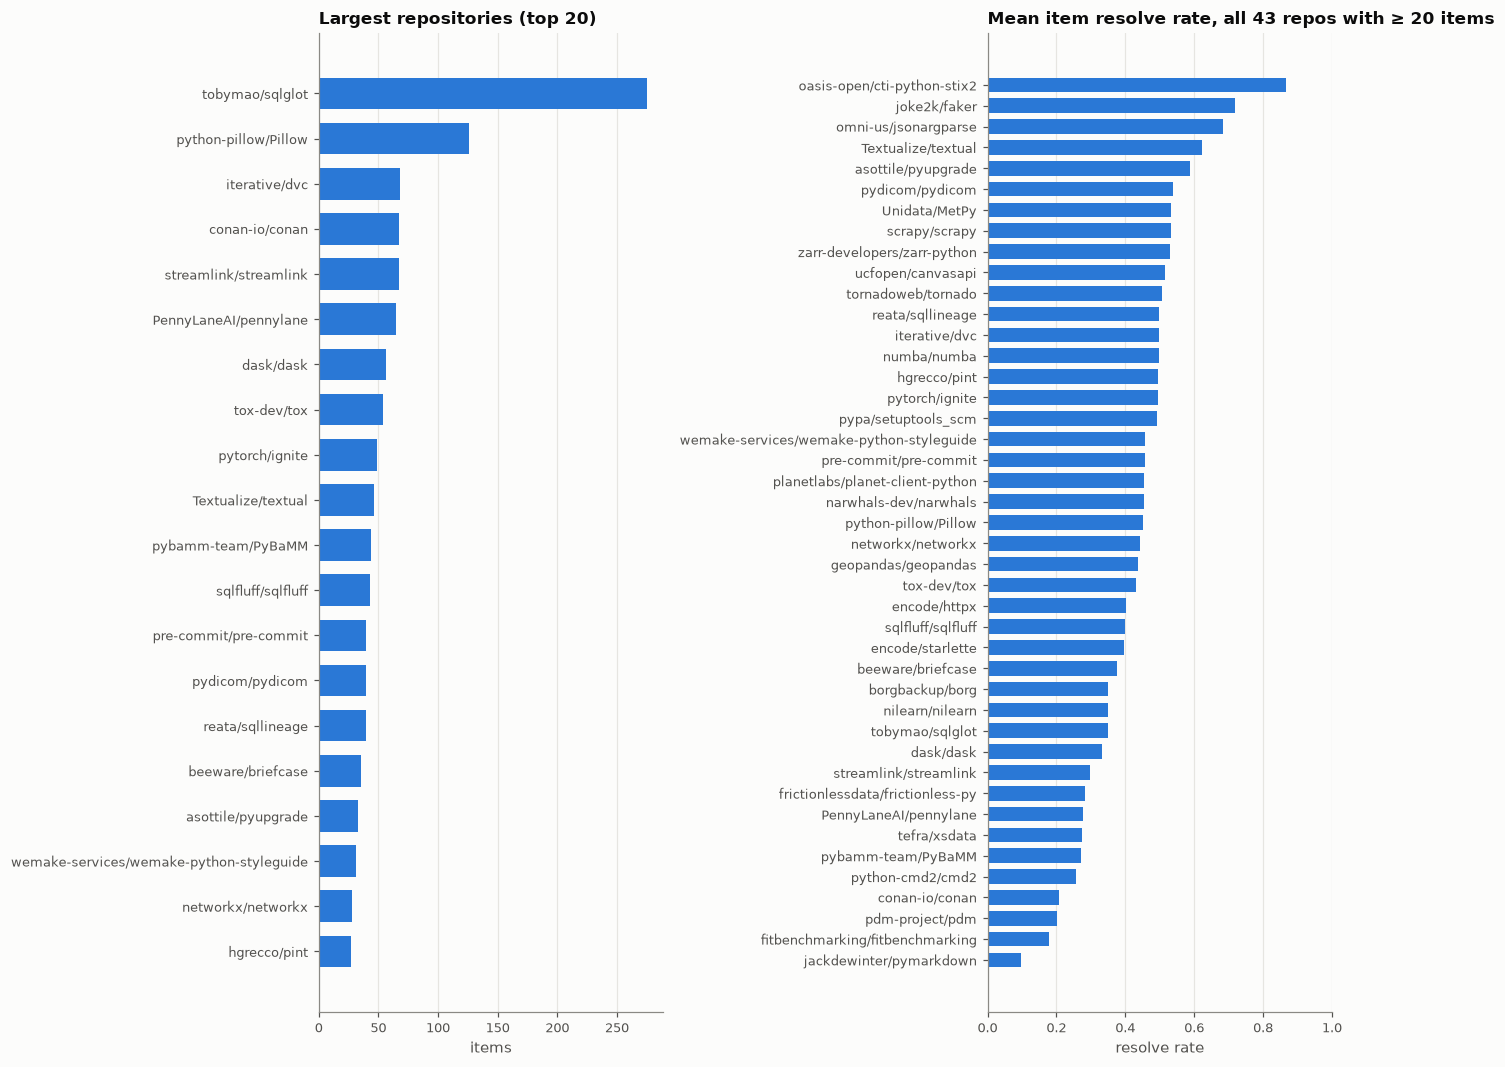

In [19]:
repo_stats = (per_item.join(items.set_index("item_id").repo)
              .groupby("repo").agg(items=("rate", "size"), runs=("n", "sum"), rate=("rate", "mean")))
print(f"{len(repo_stats):,} repos · items per repo: median {repo_stats['items'].median():.0f}, "
      f"max {repo_stats['items'].max()} · repos with a single item: {(repo_stats['items'] == 1).mean():.1%}")
top = repo_stats.sort_values("items", ascending=False)
share_top = top["items"].head(20).sum() / top["items"].sum()
print(f"top 20 repos hold {share_top:.1%} of items")

big = repo_stats[repo_stats["items"] >= 20].sort_values("rate", ascending=False)
fig, axes = panels(2, width=6.2, height=0.2 * len(big) + 1.2)
barh(axes[0], top["items"], "Largest repositories (top 20)", "items", top=20)
barh(axes[1], big.rate, f"Mean item resolve rate, all {len(big)} repos with ≥ 20 items", "resolve rate", top=len(big))
axes[1].set_xlim(0, 1)
show(fig)

between-repo share of item-rate variance: 16.5% (302 repos, 3,883 items)


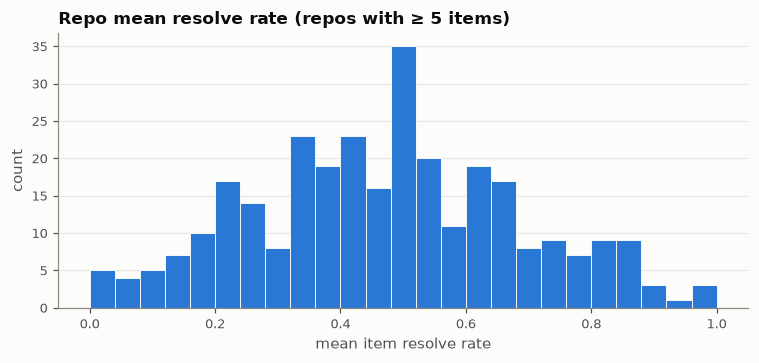

In [20]:
# How much item difficulty is explained by the repository? Between-repo share of variance (ICC-style),
# on items from repos with ≥ 5 items.
d = per_item.join(items.set_index("item_id").repo)
d = d[d.groupby("repo").rate.transform("size") >= 5]
between = d.groupby("repo").rate.transform("mean").var()
print(f"between-repo share of item-rate variance: {between / d.rate.var():.1%} "
      f"({d.repo.nunique()} repos, {len(d):,} items)")

fig, axes = panels(1, width=7)
hist(axes[0], repo_stats.loc[repo_stats["items"] >= 5, "rate"], "Repo mean resolve rate (repos with ≥ 5 items)",
     "mean item resolve rate", bins=25)
show(fig)

The benchmark is spread thinly over 1,823 repositories: 53% contribute a single item and the top 20
repos hold only 20% of items. Among repos with ≥ 5 items, the repository explains about 16% of the
variance in item difficulty: some projects are consistently easy for the agent, others hard. That is
useful signal, but it also means **random item splits leak repository identity**, so hold out
repositories for honest evaluation.

## 8. What makes an item hard

Correlates of the per-item resolve rate, using the task text, the gold patch and the tests. The gold
patch and tests are not visible to the agent, but they measure how much change the fix really needs.

,spearman_vs_rate,median
gold_lines,-0.404,17.0
gold_hunks,-0.348,3.0
f2p,-0.303,1.0
test_lines,-0.260,20.0
gold_files,-0.248,2.0
test_files,-0.224,1.0
gold_new_files,-0.091,0.0
p2p,-0.057,19.0
ps_chars,-0.034,857.0
ps_has_traceback,0.059,0.0


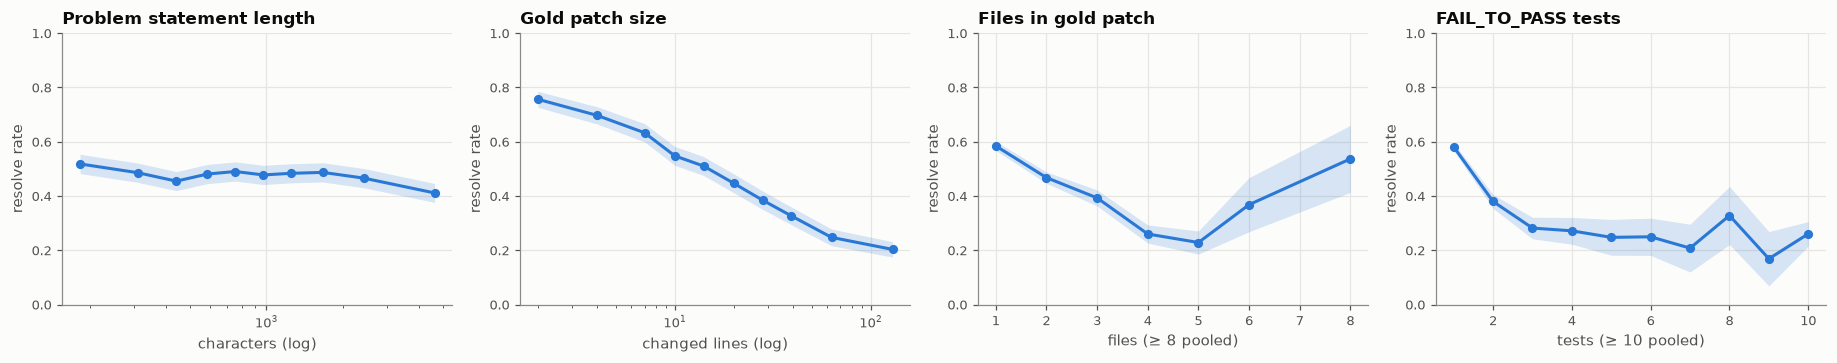

In [21]:
iv = items.set_index("item_id").join(per_item)
cols = FEATURES + ["ps_has_code", "ps_has_traceback", "gold_new_files"]
corr = pd.DataFrame({
    "spearman_vs_rate": {c: spearman(iv[c].astype(float), iv.rate) for c in cols},
    "median": iv[cols].astype(float).median(),
}).sort_values("spearman_vs_rate")
display(corr.round(3))

fig, axes = panels(4, width=4.2)
binned_rate(axes[0], iv.ps_chars, iv.rate, "Problem statement length", "characters (log)", logx=True)
binned_rate(axes[1], iv.gold_lines, iv.rate, "Gold patch size", "changed lines (log)", logx=True)
binned_rate(axes[2], iv.gold_files, iv.rate, "Files in gold patch", "files", clip=8)
binned_rate(axes[3], iv.f2p, iv.rate, "FAIL_TO_PASS tests", "tests", clip=10)
show(fig)

In [22]:
yes_no = pd.DataFrame({
    c: iv.groupby(iv[c].astype(bool)).rate.mean() for c in ["ps_has_code", "ps_has_traceback"]
} | {"gold_single_file": iv.groupby(iv.gold_files == 1).rate.mean(),
     "gold_adds_new_file": iv.groupby(iv.gold_new_files > 0).rate.mean()}).T
yes_no.columns = ["no", "yes"]
display(yes_no.round(3).rename_axis("mean item resolve rate"))

,no,yes
mean item resolve rate,,
ps_has_code,0.426,0.508
ps_has_traceback,0.461,0.514
gold_single_file,0.398,0.584
gold_adds_new_file,0.488,0.341


- The **size of the required fix** is the clearest difficulty signal: gold-patch changed lines
  (Spearman −0.40), hunks (−0.35) and the number of FAIL_TO_PASS tests (−0.30). Single-file fixes are
  solved 58% of the time vs 40% for multi-file ones (falling to ~23% at 5 files; the few larger fixes are
  too rare to read), and fixes that add a new file only 34%.
- **Problem-statement length is almost uninformative** (−0.03). Issues containing a code block or a
  traceback are somewhat easier (0.51 vs 0.43 and 0.51 vs 0.46), presumably because they come with a
  reproduction.
- Every correlation is moderate at best. Most of the difficulty variance is not captured by these
  surface features, and the strongest ones need the hidden gold patch, so they are not available before
  a task is solved.

## 9. Traces: the agent's patches

The `trace` column is the agent's final `git diff` (`model_patch` upstream), not the full multi-turn
trajectory. The step-by-step actions and observations are not shipped.

In [23]:
traces = pd.read_parquet(DIR / "traces.parquet", columns=["response_id", "trace"])
print(f"{len(traces):,} traces · response_id unique: {traces.response_id.is_unique} · "
      f"orphans: {(~traces.response_id.isin(resp.response_id)).sum()}")
assert (traces.set_index("response_id").trace.reindex(resp.response_id).fillna("").values ==
        traj.model_patch.values).all()
print("trace == raw model_patch for every run")

no_trace = ~resp.response_id.isin(traces.response_id)
print(f"runs without a trace (empty patch): {no_trace.sum()} · their resolve rate: "
      f"{resp.response[no_trace].mean():.3f} · exit status: {resp.exit_group[no_trace].value_counts().to_dict()}")

67,018 traces · response_id unique: True · orphans: 0


trace == raw model_patch for every run


runs without a trace (empty patch): 56 · their resolve rate: 0.000 · exit status: {'submitted': 42, 'hit 100-step limit': 9, 'API timeout / unavailable': 3, 'stuck in loop': 1, 'other error': 1}


All 56 empty-patch runs are graded 0, as they should be. Most of them ended with a normal `submit`: the
agent claimed to be done without changing anything.

In [24]:
ps = pd.DataFrame([patch_stats(p) for p in traces.trace], index=traces.response_id)
gold_sets = items.set_index("item_id").gold_file_set
rp = resp.set_index("response_id").join(ps, how="inner")
rp["files_n"] = rp.files.map(len)
rp["lines"] = rp.added + rp.removed
gs = gold_sets.reindex(rp.item_id).values
rp["gold_recall"] = [len(g & set(f)) / len(g) if g else np.nan for f, g in zip(rp.files, gs)]
rp["extra_src"] = [sum(1 for x in f if x not in g and not is_test_path(x)) for f, g in zip(rp.files, gs)]
rp["test_files_n"] = rp.files.map(lambda f: sum(map(is_test_path, f)))
rp["stray_scripts"] = rp.files.map(lambda f: sum(1 for x in f if "/" not in x and re.match(
    r"(test|reproduce|debug|verify|check|simple|comprehensive|final|demo)[_\-].*\.py$", x)))
del ps

rp["chars"] = traces.set_index("response_id").trace.str.len().reindex(rp.index)
display(rp[["chars", "files_n", "lines", "new_files", "test_files_n", "stray_scripts"]]
        .describe(percentiles=[0.05, 0.5, 0.95]).T.round(1))
print(f"patches that add new files: {(rp.new_files > 0).mean():.1%} · leave stray top-level scripts "
      f"(reproduce_*.py, test_*.py, …): {(rp.stray_scripts > 0).mean():.1%} · touch test paths: "
      f"{(rp.test_files_n > 0).mean():.1%}")

,count,mean,std,min,5%,50%,95%,max
chars,67018.0,10725.2,13207.7,154.0,602.0,4574.5,35543.0,127953.0
files_n,67018.0,4.5,4.9,1.0,1.0,3.0,13.0,328.0
lines,67018.0,255.5,352.5,1.0,3.0,73.0,904.0,4530.0
new_files,67018.0,3.2,4.8,0.0,0.0,1.0,11.0,325.0
test_files_n,67018.0,1.3,1.9,0.0,0.0,0.0,5.0,24.0
stray_scripts,67018.0,2.2,3.4,0.0,0.0,0.0,9.0,32.0


patches that add new files: 66.0% · leave stray top-level scripts (reproduce_*.py, test_*.py, …): 42.2% · touch test paths: 46.5%


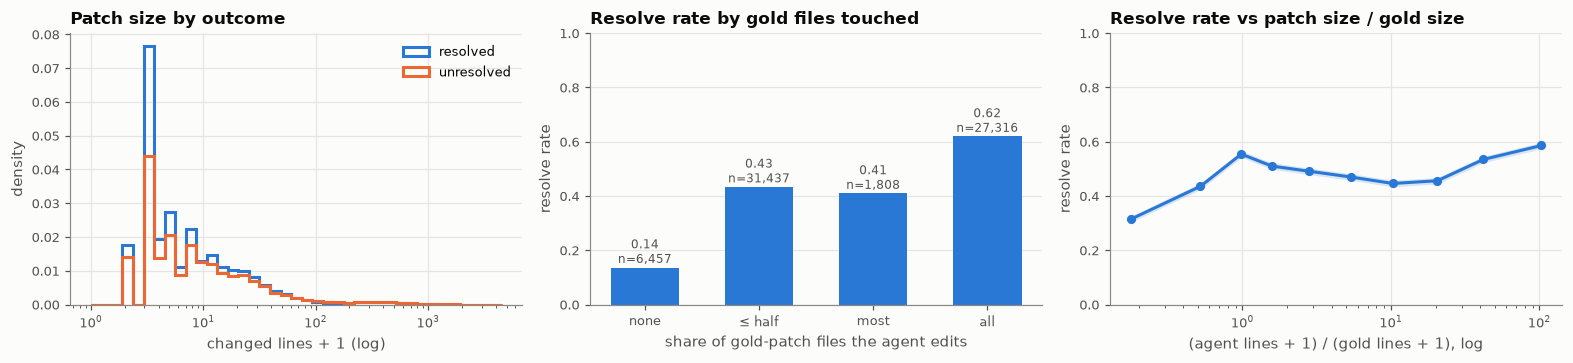

resolve rate by stray scripts left behind: {'none': 0.507, 'some': 0.443}
AUC of single-run features for resolved — gold_recall: 0.658 · −extra source files: 0.525 · −patch lines: 0.565


In [25]:
fig, axes = panels(3, width=4.8)
bins = np.logspace(0, np.log10(rp.lines.max() + 1), 40)
for score, colour, name in [(1, BLUE, "resolved"), (0, ORANGE, "unresolved")]:
    axes[0].hist(rp.lines[rp.response == score] + 1, bins=bins, histtype="step", linewidth=2, color=colour,
                 label=name, density=True)
axes[0].set_xscale("log")
axes[0].legend()
axes[0].set_title("Patch size by outcome")
axes[0].set_xlabel("changed lines + 1 (log)")
axes[0].set_ylabel("density")

rec = rp.dropna(subset=["gold_recall"]).assign(bucket=lambda d: pd.cut(
    d.gold_recall, [-0.01, 0, 0.5, 0.999, 1], labels=["none", "≤ half", "most", "all"]))
g = rec.groupby("bucket", observed=True).response.agg(["mean", "size"])
axes[1].bar(g.index.astype(str), g["mean"], color=BLUE, width=0.6)
for x, (v, n) in enumerate(zip(g["mean"], g["size"])):
    axes[1].annotate(f"{v:.2f}\nn={n:,}", (x, v), xytext=(0, 3), textcoords="offset points", ha="center",
                     fontsize=8, color=INK2)
axes[1].set_ylim(0, 1)
axes[1].set_title("Resolve rate by gold files touched")
axes[1].set_xlabel("share of gold-patch files the agent edits")
axes[1].set_ylabel("resolve rate")
axes[1].grid(axis="x", visible=False)

ratio = (rp.lines + 1) / (items.set_index("item_id").gold_lines.reindex(rp.item_id).values + 1)
binned_rate(axes[2], ratio, rp.response, "Resolve rate vs patch size / gold size", "(agent lines + 1) / (gold lines + 1), log", logx=True)
show(fig)

print("resolve rate by stray scripts left behind:",
      rp.groupby(rp.stray_scripts > 0).response.mean().round(3).rename({False: "none", True: "some"}).to_dict())
print(f"AUC of single-run features for resolved — gold_recall: {auc(rp.gold_recall, rp.response):.3f} · "
      f"−extra source files: {auc(-rp.extra_src, rp.response):.3f} · −patch lines: {auc(-rp.lines, rp.response):.3f}")

- **The agent's patches are noisy.** The median diff changes 73 lines across 3 files (the median gold
  fix: 17 lines, 2 files), 66% of patches add new files, and 42% leave throwaway top-level scripts
  (`reproduce_issue.py`, `comprehensive_test.py`, …). Some even contain junk files such as `=1.14` from a
  mistyped `pip install pkg>=1.14`. The grader ignores these extras, but anyone measuring patch size or
  similarity must strip them first.
- **Localisation is the strongest per-run signal**: runs that edit none of the gold-patch files almost
  never pass, and those that edit all of them pass most of the time (AUC 0.66 on its own). Diff size
  says little, since the scratch files dominate it.

Note these features are **post-hoc** (computed from the output) and use the hidden gold patch — useful
for understanding failures, not as pre-run predictors.

In [26]:
rng = np.random.default_rng(0)
for label, pool_ in [("resolved", rp[rp.response == 1]), ("unresolved", rp[rp.response == 0])]:
    rid = pool_.index[rng.integers(len(pool_))]
    row = rp.loc[rid]
    text = traces.set_index("response_id").trace.loc[rid]
    print(f"--- random {label} patch · {row.raw_item_id} · {row.exit_status[:40]} · {len(text):,} chars ---")
    print(textwrap.shorten(text, 700, placeholder=" …"), "\n")

--- random resolved patch · hgrecco__pint-1119 · submit · 19,421 chars ---
diff --git a/=1.14 b/=1.14 new file mode 100644 index 0000000..e69de29 diff --git a/comprehensive_test.py b/comprehensive_test.py new file mode 100644 index 0000000..2436ca1 --- /dev/null +++ b/comprehensive_test.py @@ -0,0 +1,102 @@ +#!/usr/bin/env python3 +"""Comprehensive test for the prod synchronization fix.""" + +import numpy as np +import pint + +def test_prod_synchronization(): + """Test that q.prod() and np.prod(q) give the same results.""" + ureg = pint.UnitRegistry() + Q_ = ureg.Quantity + + print("=== Comprehensive Prod Synchronization Test ===") + + # Test 1: 2D array with different axes + print("\n1. Testing 2D array [[1, 2], [3, 4]] meter") + q = Q_([[1, 2], [3, 4]], … 

--- random unresolved patch · dag-hammarskjold-library__dlx-dl-123 · submit · 30,946 chars ---
diff --git a/comprehensive_test.py b/comprehensive_test.py new file mode 100644 index 0000000..7aa453a --- /dev/null +++ b/comprehensiv

## 10. Predictability baselines

How well can a single run's outcome be predicted before it happens? AUC of simple predictors on all
67k runs, from weakest to the item-level ceiling:

- **repo mean (leave-item-out)** — only the repository is known.
- **logistic regression on item features** — problem-statement and gold-patch features, 5-fold CV with
  folds split **by repository**.
- **item mean (leave-run-out)** — the item's own resolve rate on its other runs; an upper bound for any
  item-level predictor, since the remaining variance is run-to-run noise.

In [27]:
def logistic_predict(w, X):
    return 1 / (1 + np.exp(-(w[0] + X @ w[1:])))


feat_cols = ["ps_chars", "gold_files", "gold_lines", "gold_hunks", "f2p", "p2p", "test_files", "test_lines"]
Xitem = np.log1p(items.set_index("item_id")[feat_cols].astype(float))
Xitem["ps_has_code"] = items.set_index("item_id").ps_has_code.astype(float)
Xitem["ps_has_traceback"] = items.set_index("item_id").ps_has_traceback.astype(float)
Xitem["gold_new_file"] = (items.set_index("item_id").gold_new_files > 0).astype(float)
Xitem = (Xitem - Xitem.mean()) / Xitem.std()

# Item-level binomial fit (weights = runs) is equivalent to the per-run fit and much faster:
# expand to one success row and one failure row per item.
repos = items.set_index("item_id").repo.reindex(Xitem.index)
fold_of_repo = pd.Series(np.random.default_rng(0).integers(0, 5, repos.nunique()), index=repos.unique())
fold = repos.map(fold_of_repo).values
pred_item = pd.Series(np.nan, index=Xitem.index)
coefs = []
for f in range(5):
    tr, te = fold != f, fold == f
    Xi, ci, ni = Xitem.values[tr], per_item.c.reindex(Xitem.index).values[tr], per_item.n.reindex(Xitem.index).values[tr]
    # Weighted logistic regression via duplicated rows: successes (y=1, w=c) and failures (y=0, w=n−c).
    Xd = np.vstack([Xi, Xi])
    yd = np.r_[np.ones(len(Xi)), np.zeros(len(Xi))]
    wd = np.r_[ci, ni - ci]
    keep = wd > 0
    Xd, yd, wd = Xd[keep], yd[keep], wd[keep]
    Xw = np.column_stack([np.ones(len(Xd)), Xd])
    w = np.zeros(Xw.shape[1])
    pen = np.r_[0, np.full(Xd.shape[1], 1.0)]
    for _ in range(25):
        p = 1 / (1 + np.exp(-Xw @ w))
        grad = Xw.T @ (wd * (p - yd)) + pen * w
        hess = (Xw * (wd * p * (1 - p))[:, None]).T @ Xw + np.diag(pen)
        w -= np.linalg.solve(hess, grad)
    coefs.append(w)
    pred_item[Xitem.index[te]] = logistic_predict(w, Xitem.values[te])

resp["pred_features"] = pred_item.reindex(resp.item_id).values
repo_sum = resp.groupby("repo").response.transform("sum")
repo_n = resp.groupby("repo").response.transform("size")
item_sum = resp.groupby("item_id").response.transform("sum")
item_n = resp.groupby("item_id").response.transform("size")
resp["pred_repo"] = ((repo_sum - item_sum) / (repo_n - item_n)).where(repo_n > item_n)

rows = {
    "repo mean (leave-item-out)": resp.pred_repo,
    "logistic, item features (repo-grouped CV)": resp.pred_features,
    "item mean (leave-run-out) — ceiling": resp.item_rate_loo,
}
display(pd.DataFrame({
    "AUC": {k: auc(v, resp.response) for k, v in rows.items()},
    "runs scored": {k: v.notna().sum() for k, v in rows.items()},
}).round(3))
display(pd.Series(np.mean(coefs, axis=0)[1:], index=Xitem.columns).sort_values()
        .round(3).to_frame("mean standardised coefficient"))

,AUC,runs scored
repo mean (leave-item-out),0.606,56942
"logistic, item features (repo-grouped CV)",0.724,67074
item mean (leave-run-out) — ceiling,0.974,67050


,mean standardised coefficient
gold_lines,-0.545
f2p,-0.269
ps_chars,-0.244
test_files,-0.188
gold_hunks,-0.162
test_lines,-0.123
gold_new_file,-0.103
p2p,-0.052
ps_has_traceback,0.072
gold_files,0.137


| predictor | AUC |
|---|---|
| repository only | 0.61 |
| 11 hand-made item features (repo-held-out) | 0.72 |
| the item's own other runs (ceiling) | 0.97 |

Item identity explains almost everything (ceiling 0.97), so this benchmark is essentially an
item-difficulty problem. Simple features, dominated by gold-patch size, reach 0.72. The gap between 0.72
and 0.97 is the room left for richer item representations (issue-text embeddings, code-base features).
The coefficients are collinear (`gold_files` flips sign once `gold_lines` and `gold_hunks` are in the
model), so read them jointly, not one by one.

## 11. Reproduction checks

`reproducibility.yaml` defines a `luna_medium` profile: three frozen random tasks, re-run with
`gpt-5.6-luna` in the released OpenHands scaffold and graded natively, under a $0.10 budget. It is an
execution/grading pilot, not a score reproduction.

In [28]:
repro = yaml.safe_load((DIR / "reproducibility.yaml").read_text())
prof = repro["profiles"]["luna_medium"]
print("tasks:", prof["tasks"])
print("limitations:", *("- " + l for l in repro["verification"]["limitations"]), sep="\n")
sel = json.loads((DIR / "reproduction_checks" / "selection.json").read_text())
print(f"\nselection: {sel['design']} · eligible {sel['eligible_count']:,} · algorithm: {sel['algorithm']}")

runs = sorted((DIR / "reproduction_checks" / "run_results").glob("*-bash-pilot"))
display(pd.DataFrame([{
    "run": p.name,
    "status": (res := json.loads((p / "result.json").read_text()))["status"],
    "stages": {k: v["status"] for k, v in res["stages"].items()},
    "raw_unchanged": res.get("raw_unchanged"),
    "note": short(res.get("execution_note", ""), 90),
} for p in runs]).set_index("run"))

fresh = runs[-1] / "fresh_results.json"
if fresh.exists():
    display(pd.DataFrame(json.loads(fresh.read_text())["tasks"])[["task", "status", "api_attempts", "reason"]])
controls = runs[-1] / "exercise.json"
if controls.exists():
    ex = json.loads(controls.read_text())
    cols = ["completed_instances", "resolved_instances", "unresolved_instances", "empty_patch_instances"]
    display(pd.DataFrame({k: {c: v[c] for c in cols} | {"resolved_ids": v["resolved_ids"]} for k, v in ex.items()})
            .T.rename_axis("grading control"))

released = resp[resp.raw_item_id.isin(prof["tasks"])].groupby("raw_item_id").response.agg(runs="size", rate="mean")
display(released.round(3).rename_axis("released Qwen3-Coder results for the pilot tasks"))

tasks: ['iamjackg__md2cf-97', 'coderedcorp__wagtail-cache-62', 'fgmacedo__python-statemachine-425']
limitations:
- Three tasks test execution and grading; they do not reproduce historical model scores.
- Captured raw inputs remain immutable; installations use writable run directories.
- Model and grading failures remain distinct from setup and cost interruptions.
- No replacement of unavailable or failed randomly selected tasks.

selection: Three tasks without replacement from the complete eligible list · eligible 6,306 · algorithm: SHA256(seed NUL benchmark NUL kind NUL identifier), ascending priority


,status,stages,raw_unchanged,note
run,,,,
20260918T171842-bash-pilot,failed,"{'capture': 'passed', 'prepare': 'failed'}",True,
20260918T172300-bash-pilot,blocked,"{'capture': 'passed', 'prepare': 'failed'}",True,Initial setup failed; the same frozen tasks were resumed using the recorded ...


,task,status,api_attempts,reason
0,coderedcorp__wagtail-cache-62,blocked,0,The upstream reference-solution/empty-patch grading controls did not separat...
1,fgmacedo__python-statemachine-425,provider_error,1,Provider rejected tool calls with medium reasoning through Chat Completions;...
2,iamjackg__md2cf-97,budget_exhausted,0,NaN


,completed_instances,resolved_instances,unresolved_instances,empty_patch_instances,resolved_ids
grading control,,,,,
gold,3,2,1,0,"[fgmacedo__python-statemachine-425, iamjackg__md2cf-97]"
empty,0,0,0,3,[]


,runs,rate
released Qwen3-Coder results for the pilot tasks,,
coderedcorp__wagtail-cache-62,7,0.000
fgmacedo__python-statemachine-425,7,0.000
iamjackg__md2cf-97,8,0.875


- Neither pilot produced a fresh graded attempt. The first failed during setup. The second resumed and
  ran the grading controls, then got one provider error (a rejected tool call) before the $0.10 cap was
  reserved.
- **The grading controls did not fully pass.** The gold patch should resolve all three tasks, but
  `coderedcorp__wagtail-cache-62` stays unresolved even with the reference solution. The empty patch
  correctly resolves none. So at least one released Docker image does not reproduce the upstream
  grading, and the Qwen3-Coder zero on that task (0/7 runs) may partly be an environment artefact.
- This matches `data/reproduction_results.md`: the harness is only partially verified, and no
  historical score has been reproduced.

## 12. Conclusions

**Data quality**
- Clean and internally consistent: row counts match the build claims, there are no missing scores or
  duplicate (item, trial) pairs, and responses, traces and the raw trajectory release align row-for-row.
- `item_features` is empty. Repo, gold patch, tests and Docker image have to be parsed out of
  `verifier.spec`. `exit_status` is only in `raw/openhands_trajectories.parquet`.
- 68 items share a problem statement with another item (33 groups, different PRs for the same issue).
- The covered 6,306 items are a **biased 30% sample** of the upstream pool, with ~3× smaller gold fixes.

**Design**
- One subject only (Qwen3-Coder-480B + OpenHands v0.54.0). There is no subject variation, so the
  benchmark is informative about items, not models.
- Unbalanced repeats (1–34 runs, median 10), but the number of runs does not relate to difficulty and
  runs are exchangeable (no trial-order effect).

**Outcomes**
- Resolve rate 0.48 per run. Items are U-shaped: 33% always solved, 40% never, 28% mixed.
  pass@10 ≈ 0.61.
- Item difficulty is very reliable (split-half 0.95; 97% of the variance is between items). Two runs
  of the same item agree 90% of the time.
- Failures: 9% of runs hit the 100-step limit (they still pass 18% of the time). Infrastructure errors
  are rare (~0.1%) and should be treated as missing.

**What predicts success**
- Repository explains ~16% of difficulty, so split by repo.
- The size of the required fix (gold lines, hunks, FAIL_TO_PASS count) is the best simple predictor.
  Issue length is uninformative.
- Per run, editing the right files is what matters most. The agent's diffs are inflated by scratch
  scripts.
- Predicting a single run: AUC 0.61 from the repo, 0.72 from simple features, 0.97 from the item's own
  other runs.

**Reproducibility**
- The re-run pilot never completed a fresh attempt, and one of three tasks fails its gold-patch control.
  Environment breakage may account for some "never solved" items.